In [4]:
import pandas as pd
import matplotlib.pyplot as plt

t2012 = pd.read_excel("Tabela5-sem_emprego_2012.xlsx")
t2026 = pd.read_excel("Tabela5-sem_emprego_2026.xlsx")

print(t2012.head())
print(t2026.head())



tabela_horas = pd.read_excel(
    "Tabela 1.1.1 (1).xlsx",
    sheet_name="2022",
    header=None
)

  Sigla  Código    Estado  Desocupados - homens (2012 T1)  \
0    AC      12      Acre                            45.3   
1    AL      27   Alagoas                            44.7   
2    AM      13  Amazonas                            47.5   
3    AP      16     Amapá                            48.1   
4    BA      29     Bahia                            43.8   

   Desocupados - mulheres (2012 T1)  
0                              54.7  
1                              55.3  
2                              52.5  
3                              51.9  
4                              56.2  
  Sigla  Código    Estado  Desocupados - homens (2026 T1)  \
0    AC      12      Acre                            53.2   
1    AL      27   Alagoas                            50.7   
2    AM      13  Amazonas                            46.8   
3    AP      16     Amapá                            51.1   
4    BA      29     Bahia                            44.7   

   Desocupados - mulheres (2026 T1)  


In [5]:
comp = t2012.merge(
    t2026,
    on=["Sigla", "Código", "Estado"],
    how="inner"
)

print("\n===== COMPARAÇÃO 2012 x 2026 =====")
print(comp)


===== COMPARAÇÃO 2012 x 2026 =====
   Sigla  Código               Estado  Desocupados - homens (2012 T1)  \
0     AC      12                 Acre                            45.3   
1     AL      27              Alagoas                            44.7   
2     AM      13             Amazonas                            47.5   
3     AP      16                Amapá                            48.1   
4     BA      29                Bahia                            43.8   
5     CE      23                Ceará                            51.1   
6     DF      53     Distrito Federal                            41.0   
7     ES      32       Espírito Santo                            46.4   
8     GO      52                Goiás                            41.0   
9     MA      21             Maranhão                            47.2   
10    MG      31         Minas Gerais                            43.1   
11    MS      50   Mato Grosso do Sul                            47.2   
12    MT      5

In [6]:
comp["Variação homens"] = (
    comp["Desocupados - homens (2026 T1)"]
    - comp["Desocupados - homens (2012 T1)"]
)

comp["Variação mulheres"] = (
    comp["Desocupados - mulheres (2026 T1)"]
    - comp["Desocupados - mulheres (2012 T1)"]
)

print("\n===== VARIAÇÃO DA DESOCUPAÇÃO =====")
print(
    comp[
        [
            "Sigla",
            "Estado",
            "Variação homens",
            "Variação mulheres"
        ]
    ]
)


===== VARIAÇÃO DA DESOCUPAÇÃO =====
   Sigla               Estado  Variação homens  Variação mulheres
0     AC                 Acre              7.9               -7.9
1     AL              Alagoas              6.0               -6.0
2     AM             Amazonas             -0.7                0.7
3     AP                Amapá              3.0               -3.0
4     BA                Bahia              0.9               -0.9
5     CE                Ceará              1.6               -1.6
6     DF     Distrito Federal              6.9               -6.9
7     ES       Espírito Santo              1.1               -1.1
8     GO                Goiás              6.5               -6.5
9     MA             Maranhão              1.9               -1.9
10    MG         Minas Gerais              5.5               -5.5
11    MS   Mato Grosso do Sul             -1.9                1.9
12    MT          Mato Grosso             -1.3                1.3
13    PA                 Pará          

In [7]:
maior_aumento_homens = comp.loc[
    comp["Variação homens"].idxmax()
]

maior_aumento_mulheres = comp.loc[
    comp["Variação mulheres"].idxmax()
]

print("\n===== MAIORES AUMENTOS =====")

print(
    "Homens:",
    maior_aumento_homens["Estado"],
    "->",
    maior_aumento_homens["Variação homens"],
    "pontos percentuais"
)

print(
    "Mulheres:",
    maior_aumento_mulheres["Estado"],
    "->",
    maior_aumento_mulheres["Variação mulheres"],
    "pontos percentuais"
)


===== MAIORES AUMENTOS =====
Homens: Acre -> 7.900000000000006 pontos percentuais
Mulheres: Rondônia -> 10.399999999999999 pontos percentuais


In [8]:
horas = tabela_horas.iloc[8:].copy()

horas = horas.iloc[:, :6]

horas.columns = [
    "Estado",
    "Total",
    "Homem branca",
    "Homem preta ou parda",
    "Mulher branca",
    "Mulher preta ou parda"
]


horas = horas.dropna(subset=["Estado"])

print("\n===== TABELA DE HORAS - IBGE 2022 =====")
print(horas)


===== TABELA DE HORAS - IBGE 2022 =====
                                               Estado      Total Homem branca  \
8                                              Brasil  16.985781     16.54593   
9                                               Norte  16.187037    15.925246   
10                                           Rondônia  17.014162    16.727733   
11                                               Acre  13.606903    13.806929   
12                                           Amazonas   16.80729    15.987545   
13                                            Roraima  13.639257    13.651755   
14                                               Pará  16.474268    16.181627   
15                                              Amapá  13.586656     14.38918   
16                                          Tocantins  15.815781    15.701788   
17                                           Nordeste  18.499396      18.1517   
18                                           Maranhão  16.669614    

In [9]:
horas["Estado"] = (
    horas["Estado"]
    .astype(str)
    .str.strip()
)

comp["Estado"] = (
    comp["Estado"]
    .astype(str)
    .str.strip()
)

In [10]:
final = comp.merge(
    horas,
    on="Estado",
    how="inner"
)

print("\n===== TABELA FINAL =====")
print(final)



===== TABELA FINAL =====
   Sigla  Código               Estado  Desocupados - homens (2012 T1)  \
0     AC      12                 Acre                            45.3   
1     AL      27              Alagoas                            44.7   
2     AM      13             Amazonas                            47.5   
3     AP      16                Amapá                            48.1   
4     BA      29                Bahia                            43.8   
5     CE      23                Ceará                            51.1   
6     DF      53     Distrito Federal                            41.0   
7     ES      32       Espírito Santo                            46.4   
8     GO      52                Goiás                            41.0   
9     MA      21             Maranhão                            47.2   
10    MG      31         Minas Gerais                            43.1   
11    MS      50   Mato Grosso do Sul                            47.2   
12    MT      51         

In [11]:
print("\n===== RESULTADOS =====")

print("\nEstado | Homens 2012 | Homens 2026 | Mulheres 2012 | Mulheres 2026")

for _, linha in comp.iterrows():
    print(
        linha["Estado"],
        "|",
        linha["Desocupados - homens (2012 T1)"],
        "|",
        linha["Desocupados - homens (2026 T1)"],
        "|",
        linha["Desocupados - mulheres (2012 T1)"],
        "|",
        linha["Desocupados - mulheres (2026 T1)"]
    )



===== RESULTADOS =====

Estado | Homens 2012 | Homens 2026 | Mulheres 2012 | Mulheres 2026
Acre | 45.3 | 53.2 | 54.7 | 46.8
Alagoas | 44.7 | 50.7 | 55.3 | 49.3
Amazonas | 47.5 | 46.8 | 52.5 | 53.2
Amapá | 48.1 | 51.1 | 51.9 | 48.9
Bahia | 43.8 | 44.7 | 56.2 | 55.3
Ceará | 51.1 | 52.7 | 48.9 | 47.3
Distrito Federal | 41.0 | 47.9 | 59.0 | 52.1
Espírito Santo | 46.4 | 47.5 | 53.6 | 52.5
Goiás | 41.0 | 47.5 | 59.0 | 52.5
Maranhão | 47.2 | 49.1 | 52.8 | 50.9
Minas Gerais | 43.1 | 48.6 | 56.9 | 51.4
Mato Grosso do Sul | 47.2 | 45.3 | 52.8 | 54.7
Mato Grosso | 44.1 | 42.8 | 55.9 | 57.2
Pará | 43.2 | 48.3 | 56.8 | 51.7
Paraíba | 44.4 | 48.9 | 55.6 | 51.1
Pernambuco | 43.9 | 48.7 | 56.1 | 51.3
Piauí | 51.2 | 55.1 | 48.8 | 44.9
Paraná | 40.3 | 46.3 | 59.7 | 53.7
Rio de Janeiro | 44.2 | 45.4 | 55.8 | 54.6
Rio Grande do Norte | 51.0 | 48.2 | 49.0 | 51.8
Rondônia | 43.4 | 33.0 | 56.6 | 67.0
Roraima | 41.8 | 43.4 | 58.2 | 56.6
Rio Grande do Sul | 42.8 | 47.4 | 57.2 | 52.6
Santa Catarina | 42.7 | 44

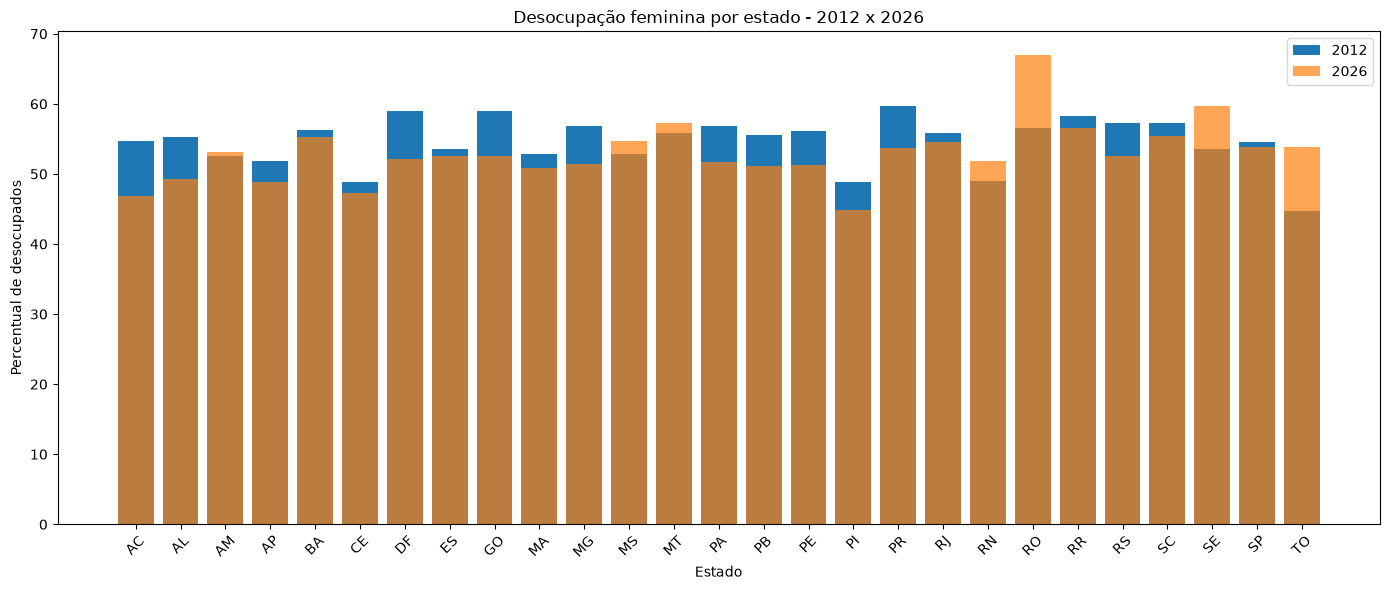

In [12]:
plt.figure(figsize=(14, 6))

plt.bar(
    comp["Sigla"],
    comp["Desocupados - mulheres (2012 T1)"],
    label="2012"
)

plt.bar(
    comp["Sigla"],
    comp["Desocupados - mulheres (2026 T1)"],
    alpha=0.7,
    label="2026"
)

plt.title("Desocupação feminina por estado - 2012 x 2026")
plt.xlabel("Estado")
plt.ylabel("Percentual de desocupados")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

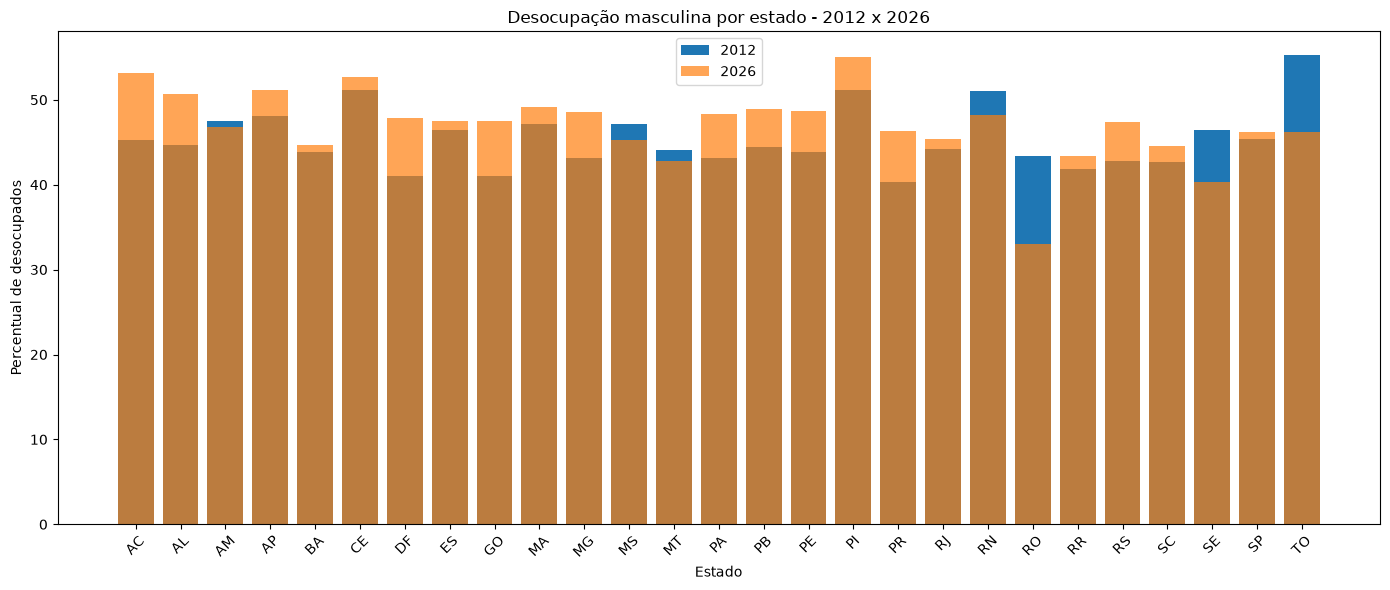

In [13]:
plt.figure(figsize=(14, 6))

plt.bar(
    comp["Sigla"],
    comp["Desocupados - homens (2012 T1)"],
    label="2012"
)

plt.bar(
    comp["Sigla"],
    comp["Desocupados - homens (2026 T1)"],
    alpha=0.7,
    label="2026"
)

plt.title("Desocupação masculina por estado - 2012 x 2026")
plt.xlabel("Estado")
plt.ylabel("Percentual de desocupados")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

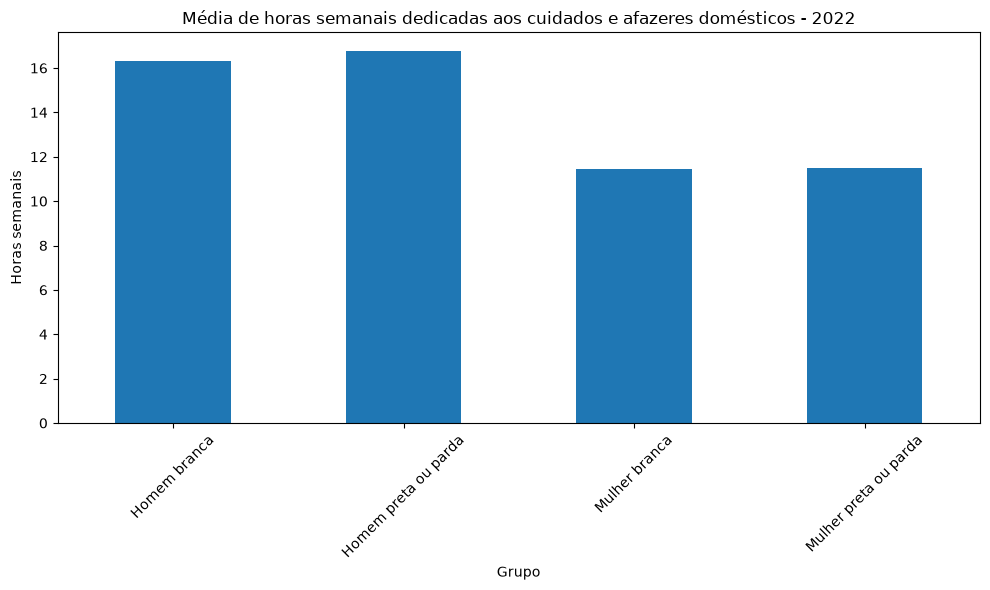

In [14]:
colunas_horas = [
    "Homem branca",
    "Homem preta ou parda",
    "Mulher branca",
    "Mulher preta ou parda"
]

for coluna in colunas_horas:
    final[coluna] = pd.to_numeric(
        final[coluna],
        errors="coerce"
    )

media_horas = final[colunas_horas].mean()

plt.figure(figsize=(10, 6))

media_horas.plot(
    kind="bar"
)

plt.title(
    "Média de horas semanais dedicadas aos cuidados "
    "e afazeres domésticos - 2022"
)

plt.xlabel("Grupo")
plt.ylabel("Horas semanais")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [18]:
comp = t2012.merge(
    t2026,
    on=["Sigla", "Código", "Estado"],
    how="inner"
)


comp["Variação homens"] = (
    comp["Desocupados - homens (2026 T1)"]
    - comp["Desocupados - homens (2012 T1)"]
)



comp["Variação mulheres"] = (
    comp["Desocupados - mulheres (2026 T1)"]
    - comp["Desocupados - mulheres (2012 T1)"]
)